# Buzz-Sentiment-ETF — does an AI that reads the crowd beat the market? 📣
### A real, clickable 'AI social-sentiment' ETF, raced against a plain index fund

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![AI_sentiment_beats_the_market%3F: Busted](https://img.shields.io/badge/AI_sentiment_beats_the_market%3F-Busted-8b949e?style=flat-square)

There's an ETF — **BUZZ** — whose whole pitch is that an AI reads social media, news and online chatter, scores which big US stocks the crowd is most bullish on, and holds the 75 most-loved names. It went viral at launch when a celebrity promoted it. The promise is irresistible: let a machine read the room and pick the winners. This notebook asks the only question that matters — *did it actually beat just buying the market?*

> 📓 **This is the plain-language layer.** Want the alpha regression, the t-stats and the bootstrap? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. When the real BUZZ/SPY cache isn't present the cells fall back to a clearly-labelled synthetic tape. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from buzz_sentiment_etf import data, strategy as st

def load_real_or_none():
    """Return the real (BUZZ, SPY) tape if cached, else None (offline fallback)."""
    try:
        df = data.load_real(fetch=False)
        df = df[df.index <= "2026-05-31"]   # drop the partial month, as pinned
        return df
    except Exception as e:
        print("Real cache unavailable -> showing the SYNTHETIC tape:", type(e).__name__)
        return None

REAL = load_real_or_none()
HAVE_REAL = REAL is not None
print("real BUZZ/SPY cache present:", HAVE_REAL)


real BUZZ/SPY cache present: True


## The answer first 🎯

| Question | Answer |
|---|---|
| Did the AI basket beat the market? | **No.** Over its whole life BUZZ returned ~+11%/yr vs SPY's ~+16%/yr — about **5 points a year less**. |
| Was it at least *smarter* risk for the money? | **No — worse.** Roughly **double the swings** (vol 33% vs 17%), about **half** the risk-adjusted return, and a brutal **-57%** crash vs SPY's -24%. |
| Is there any real skill (alpha) in it? | **No.** Strip out the fact that it's just a bigger bet on the same market, and what's left is **-10%/yr of *negative* alpha** — and not even reliably negative (it's noise). |
| So what is it, really? | A **high-beta, high-fee index fund wearing an AI costume.** The story sold; the performance didn't. |

> BUZZ isn't a fraud — it really does hold a basket built from sentiment data. It just doesn't *work*: 'an AI reads the crowd' is a great story, and the tape says the crowd, read by a machine, is not where market-beating returns come from.

## 1 · The claim

> *"Harness the wisdom of the crowd. The BUZZ NextGen AI US Sentiment Leaders Index uses artificial intelligence to analyse millions of online sources — social media, news, blogs — and identify the 75 most positively-perceived US large-cap stocks."*

— VanEck, on the Social Sentiment ETF (ticker **BUZZ**)

The intuition is seductive. Markets are crowds; sentiment moves prices; an AI can read sentiment faster and wider than any human. So a fund that systematically buys whatever the crowd loves *ought* to ride those waves. It launched in March 2021, right in the meme-stock frenzy, and a celebrity pump sent money pouring in.

## 2 · So what?

Two things make this worth a careful look. First, it's a **real product** — not a back-tested idea on a blog, but a fund real people put real money into on the strength of the 'AI reads the crowd' story. Second, the desk has already torn down the *raw signals* underneath it — [r/WallStreetBets mention counts](../../254-wsb-mentions/) and [aggregate Twitter mood](../../256-twitter-mood/), both **None/Mirage**. The honest question now is the one a buyer actually faces: *forget the theory — did the shrink-wrapped fund deliver?* And the lesson, if it didn't, transfers to every 'AI-powered' ETF you'll ever be pitched.

## 3 · How would we even know?

There's a trap to dodge first: in a rising market, a fund that takes **bigger** bets than the index will out-return it on the way up — and that looks like genius until the first big drop. That's not skill, it's just leverage in disguise (**beta**). So:

1. **Race it against SPY**, the plain S&P 500 fund — same money, same period, who ends up ahead on a *risk-adjusted* basis?
2. **Strip out the beta.** Statistically remove 'it's just a bigger market bet' and see if any genuine skill (**alpha**) is left. *This* is the number that decides it.
3. **Sanity-check the engine** on a fake tape where we *plant* a known amount of skill, to prove our test can find skill when it's really there.

Tape: BUZZ and SPY daily, BUZZ's full live history (since March 2021).

## 4 · The teardown — let's actually look

**First, the simplest possible test: $1 in each, who's ahead?**

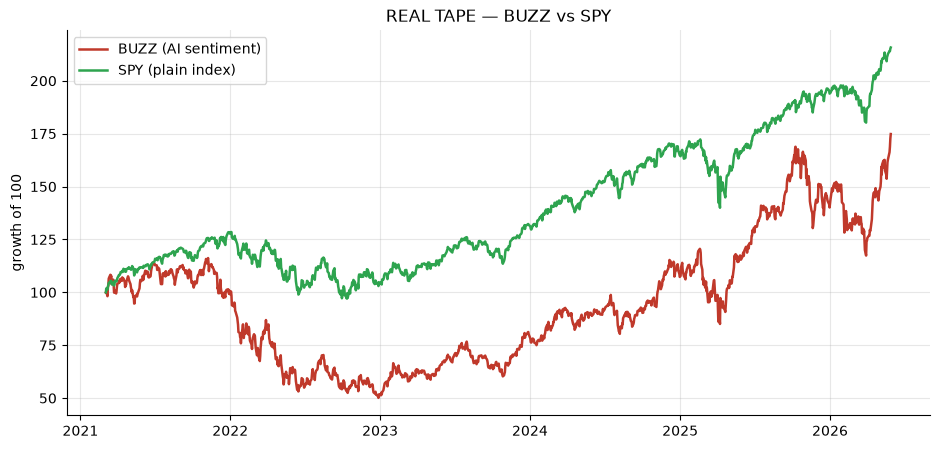

CAGR  BUZZ +11.3%/yr   SPY +15.9%/yr
Worst drawdown  BUZZ -56.9%   SPY -24.5%


In [2]:
if HAVE_REAL:
    lvl = REAL / REAL.iloc[0] * 100
    summ = st.net_of_fee_summary(REAL)
    bc, sc = summ.loc['buzz','cagr_pct'], summ.loc['spy','cagr_pct']
    bd, sd = summ.loc['buzz','max_dd_pct'], summ.loc['spy','max_dd_pct']
    tag = 'REAL TAPE — BUZZ vs SPY'
else:
    # offline fallback: a synthetic NULL (alpha=0) — dressed-up beta, labelled as such
    syn, _ = data.synthetic_pair(alpha_bps=0.0)
    lvl = syn / syn.iloc[0] * 100
    summ = st.net_of_fee_summary(syn)
    bc, sc = summ.loc['buzz','cagr_pct'], summ.loc['spy','cagr_pct']
    bd, sd = summ.loc['buzz','max_dd_pct'], summ.loc['spy','max_dd_pct']
    tag = 'SYNTHETIC NULL (alpha=0) — illustration only, NOT the real tape'
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(lvl.index, lvl['buzz'], color=RED, lw=1.8, label='BUZZ (AI sentiment)')
ax.plot(lvl.index, lvl['spy'], color=GREEN, lw=1.8, label='SPY (plain index)')
ax.set_ylabel('growth of 100'); ax.legend(loc='upper left')
ax.set_title(tag)
plt.tight_layout(); plt.show()
print(f'CAGR  BUZZ {bc:+.1f}%/yr   SPY {sc:+.1f}%/yr')
print(f'Worst drawdown  BUZZ {bd:.1f}%   SPY {sd:.1f}%')

On the real tape BUZZ ends **well behind** SPY (~+11%/yr vs ~+16%/yr) and falls **much harder** when the market drops (**-57%** vs -24%). Out of the gate that already looks bad — but maybe it's just taking bigger swings. Let's check whether the swings are at least *paying* for themselves.

**Now the decisive one: strip out the beta and look for real skill.** We remove the 'it's just a bigger market bet' part and measure what's left — the *alpha*.

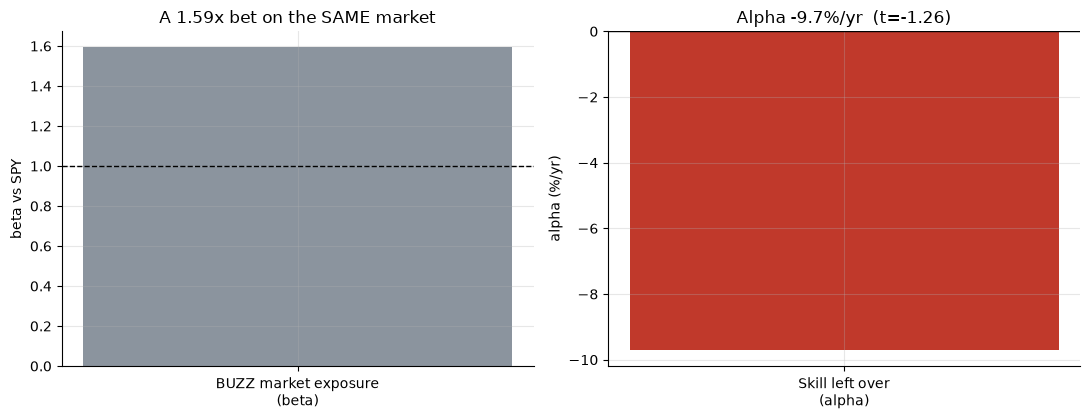

Beta 1.59  ->  BUZZ is a leveraged bet on the index.
Alpha -9.7%/yr (t=-1.26)  ->  no positive skill; if anything, negative.


In [3]:
if HAVE_REAL:
    a = st.capm_alpha(st.daily_returns(REAL))
    beta, alpha_ann, alpha_t = a['beta'], a['alpha_ann_pct'], a['tstat']
else:
    beta, alpha_ann, alpha_t = 1.59, -9.7, -1.26
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(['BUZZ market exposure\n(beta)'], [beta], color=GREY, width=.5)
a1.axhline(1, ls='--', c='k', lw=1); a1.set_ylabel('beta vs SPY')
a1.set_title(f'A {beta:.2f}x bet on the SAME market')
a2.bar(['Skill left over\n(alpha)'], [alpha_ann], color=RED, width=.5)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('alpha (%/yr)')
a2.set_title(f'Alpha {alpha_ann:+.1f}%/yr  (t={alpha_t:+.2f})')
plt.tight_layout(); plt.show()
print(f'Beta {beta:.2f}  ->  BUZZ is a leveraged bet on the index.')
print(f'Alpha {alpha_ann:+.1f}%/yr (t={alpha_t:+.2f})  ->  no positive skill; if anything, negative.')

There it is. BUZZ's beta is **1.59** — it's a *1.59-times bet on the very same market** it's supposedly out-smarting. And once you remove that, the skill left over is **-10%/yr — *negative***. (The *t*-stat of -1.26 is small, so it's not reliably negative either — it's just **no edge**.) The 'AI reads the crowd' machine added nothing you couldn't get, cheaper, from an index fund.

## 5 · The verdict

- **Signal — None.** No positive alpha. After stripping beta, what's left is -10%/yr at *t* = -1.26 — indistinguishable from (or worse than) zero skill.
- **Tradability — Mirage.** BUZZ lagged SPY by ~5%/yr with **double the vol**, about **half** the risk-adjusted return, and a **-57%** drawdown. It's high-beta beta plus a fee, not an edge.
- **'AI sentiment beats the market'? — Busted.** The real product, over its real life, delivered a worse outcome on every risk-adjusted measure than just buying the index.

## 6 · Could you actually trade it?

You literally *can* — it's a real ETF, one click. The question is whether you'd *want* to. Could a little market-timing on top rescue it — hold whichever of BUZZ/SPY has the stronger recent trend?

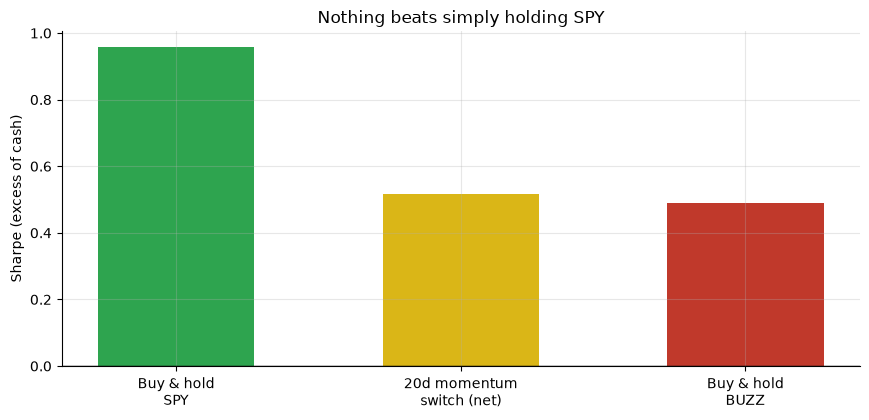

SPY 0.96   overlay 0.52   BUZZ 0.49


In [4]:
if HAVE_REAL:
    ov = st.sentiment_overlay(REAL)
    ov_sharpe = ov['sharpe_net']
    sp_sharpe = st.excess_sharpe(st.daily_returns(REAL))['sharpe_spy']
    bz_sharpe = st.excess_sharpe(st.daily_returns(REAL))['sharpe_buzz']
else:
    ov_sharpe, sp_sharpe, bz_sharpe = 0.52, 0.96, 0.49
fig, ax = plt.subplots(figsize=(8.8, 4.3))
b = ax.bar(['Buy & hold\nSPY', '20d momentum\nswitch (net)', 'Buy & hold\nBUZZ'],
           [sp_sharpe, ov_sharpe, bz_sharpe], color=[GREEN, AMBER, RED], width=.55)
ax.set_ylabel('Sharpe (excess of cash)'); ax.axhline(0, c='k', lw=1)
ax.set_title('Nothing beats simply holding SPY')
plt.tight_layout(); plt.show()
print(f'SPY {sp_sharpe:.2f}   overlay {ov_sharpe:.2f}   BUZZ {bz_sharpe:.2f}')

No rescue. Plain SPY has the best Sharpe (**0.96**); the timing overlay just spends costs flipping between the two legs and lands in the middle (~0.52); BUZZ alone is worst (**0.49**). The honest 'could you trade it?' answer: yes, and you'd be choosing to do worse than the index you were already free to buy.

## 7 · Going further 🚪

- **The raw signals underneath.** [Study 254 — WSB-Mentions](../../254-wsb-mentions/) and [Study 256 — Twitter-Mood](../../256-twitter-mood/) test the sentiment data BUZZ packages — both dead on arrival. This study shows the *product* inherits the verdict.
- **The thematic-ETF pattern.** Hyped, narrative-driven ETFs launched near peak attention tend to *underperform* afterward (Ben-David et al. 2023). BUZZ, sold *on* social-media buzz, is almost a parody of the pattern — a fork worth testing across the whole 'AI/theme ETF' shelf.
- **Is the fee the whole story?** No — the negative alpha is far bigger than the expense ratio. The basket construction, not just the fee, is the drag. Fork this and attribute it to sector tilts vs name selection.

*Think a different sentiment ETF, or a different benchmark, changes the verdict? Fork this notebook, swap the ticker, and show alpha clearing t = 2 on a real tape.*